In [1]:
import copy
from   random import choice
import math 

import numpy as np
from   sklearn.cluster import HDBSCAN, DBSCAN
import hdbscan

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import NaiveDE
import SpatialDE
import pandas as pd

import networkx as nx

from plot import *
from data import *
from filt import *
from filt import ITNI, ITSNI, VNI

from scipy.optimize import minimize
from scipy.stats import nbinom


from matplotlib.patches import Circle
from matplotlib.lines import Line2D

import scanpy
from sklearn.neighbors import NearestNeighbors

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from collections import deque

In [2]:
#Definzione colori + grafica

W  = '#efefd0'
B  = '#004e89'
Or = "#ff6b35"
mpl.rcParams['text.color']       = B
mpl.rcParams['axes.labelcolor']  = B
mpl.rcParams['axes.edgecolor']   = B
mpl.rcParams['axes.facecolor']   = W
mpl.rcParams['figure.facecolor'] = W
mpl.rcParams['xtick.color']      = B
mpl.rcParams['ytick.color']      = B
mpl.rcParams['font.family']      = "monospace"

c1 = "#35cde2"
c2 = "#ab2b2b"

colors    = [B, Or]
cmap_name = "balck_yellow"
myCMAP    = LinearSegmentedColormap.from_list(cmap_name, colors)

mpl.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 20,    
    "legend.fontsize": 14,
})

cmap_3 = ListedColormap([
    (0,0,0,0),  # 0 -> trasparente
    c1,         # 1 -> solo A
    c2,         # 2 -> solo B
    Or          # 3 -> A ∩ B
])

In [3]:
def plot_spatial_scatter(
        data, 
        gene_data, 
        ax           = None, 
        cmap         = CMAP, 
        figsize      = FIGSIZE, 
        spines_color = B,
        size         = None, 
        shape        = SHAPE,
        title = "",
        bottom_text=None,
        bottom_pad=-0.08):
    if not ax: 
        ax = plt.gca()
    
    data.obs["show_gene"] = gene_data
    sq.pl.spatial_scatter(
            data, 
            shape     = shape,
            color     = "show_gene", 
            figsize   = figsize,
            cmap      = cmap,
            colorbar  = COLORBAR,
            img_alpha = IMG_ALPHA,
            ax        = ax,
            size      = size
            )
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title(title)

    ax.spines['bottom'].set_color(spines_color)
    ax.spines['top'].set_color(spines_color)
    ax.spines['right'].set_color(spines_color)
    ax.spines['left'].set_color(spines_color)

    if bottom_text:
        ax.text(
            0.5, bottom_pad, bottom_text,
            transform=ax.transAxes,
            ha="center", va="top"
        )

In [4]:
scdata = load_data()
pgdata = np.load("trasnformed_gdata.npy")
df_meta = pd.read_csv("1.DLPFC/151673/metadata.tsv", sep='\t')
coords = df_meta[['imagecol', 'imagerow']].to_numpy(np.float32)
scdata.obsm['X_spatial'] = coords


original_gene_ids = np.load("transformed_gdata_gene_ids.npy")


/home/cero/Desktop/Uni/Tesi_Cerinelli/.venv/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/cero/Desktop/Uni/Tesi_Cerinelli/.venv/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [5]:
index_to_cart = np.zeros((len(scdata.obs), 2))
max_row       = scdata.obs['array_row'].max()
for i, ind in enumerate(scdata.obs.index):
    col = scdata.obs['array_col'][ind]
    row = scdata.obs['array_row'][ind]
    index_to_cart[i, 0] = col             * (np.sqrt(3)/2)
    index_to_cart[i, 1] = (max_row - row) * (3/2)

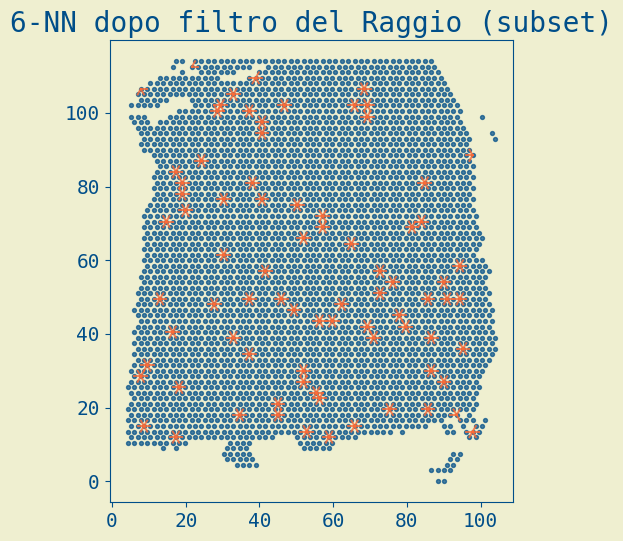

In [6]:
coords = index_to_cart  # shape: (n_spot, 2)
k = 1 + 6               # +1 perché include anche se stesso
nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(coords)
dists, inds = nbrs.kneighbors(coords)

i = 0
vicini6 = inds[i, 1:]
distanze = dists[i, 1:]

# --- filtro per raggio ---
R = 1.74 

# liste di vicini/distanze filtrate per ogni nodo
vicini_filtrati  = []
distanze_filtrate = []

for i in range(len(coords)):
    di = dists[i, 1:]   # salta se stesso
    ii = inds[i, 1:]
    mask = di <= R      # "maggiore di R" viene rimosso
    vicini_filtrati.append(ii[mask])
    distanze_filtrate.append(di[mask])

np.random.seed(3)
sample = np.random.choice(len(coords), size=min(80, len(coords)), replace=False)

plt.figure(figsize=(6,6))
plt.scatter(coords[:,0], coords[:,1], s=8, alpha=0.7, facecolors=W, edgecolors=B, c=B)
for u in sample:
    for v in vicini_filtrati[u]:
        plt.plot([coords[u,0], coords[v,0]],
                 [coords[u,1], coords[v,1]],
                 lw=1.4, alpha=0.8,  color=Or)
plt.gca().set_aspect('equal'); plt.title('6-NN dopo filtro del Raggio (subset)')
plt.savefig("presentazioneCerinelli/SpotViciniFiltratiPerRaggio", dpi=1000)
plt.show()

In [7]:
binaryMasks = np.load("trasnformed_gdata.npy")  #tutte le binary mask dei 900 geni. 
number_of_genes = len(binaryMasks) 
number_of_spots = len(binaryMasks[0])
spat_var_genes = np.load("spatially_variable_genes.npy")
smallest   = select_top_spatially_variable_genes(scdata, 3000, 500, 3000)
gene_ids   = np.intersect1d(smallest, spat_var_genes)
gene_names = scdata.var.index.to_numpy()
array_data = scdata.X.toarray().T
print("ciaoo")


ciaoo


In [8]:
def component_to_mask(component, number_of_spots):
    # Crea una maschera binaria (array di 0/1) lunga quanto la binary mask originale.
    mask = np.zeros(number_of_spots, dtype=int)
    mask[list(component)] = 1
    return mask


In [9]:
def connected_components_on_mask(mask, neighbors, number_of_spots, min_size=1, return_masks=True):
    
    mask = np.asarray(mask).astype(bool)
    n = len(mask)
    visited = np.zeros(n, dtype=bool)
    comp_labels = -1 * np.ones(n, dtype=int)
    components = []
    comp_masks = [] if return_masks else None
    cid = 0

    # Consideriamo solo i nodi attivi
    active_nodes = np.flatnonzero(mask)

    for start in active_nodes:
        if visited[start]:
            continue
        # Avvia BFS solo se il nodo è attivo
        if not mask[start]:
            continue

        q = deque([start])
        visited[start] = True
        comp = []

        while q:
            u = q.popleft()
            comp.append(u)
            # espandi solo verso vicini attivi
            for v in neighbors[u]:
                if v < 0 or v >= n:
                    continue
                if mask[v] and not visited[v]:
                    visited[v] = True
                    q.append(v)

        # Applica soglia dimensione componente
        if len(comp) >= min_size:
            for u in comp:
                comp_labels[u] = cid
            components.append(comp)
            cid += 1

            if return_masks:
                comp_masks.append(component_to_mask(comp,number_of_spots))
        # altrimenti la scarti e lasci -1
    
    if return_masks:
        return comp_labels, components, comp_masks
    else:
        return comp_labels, components

Trovati 4 cluster >=5 spot
Taglie cluster: [1561, 23, 7, 10] ...


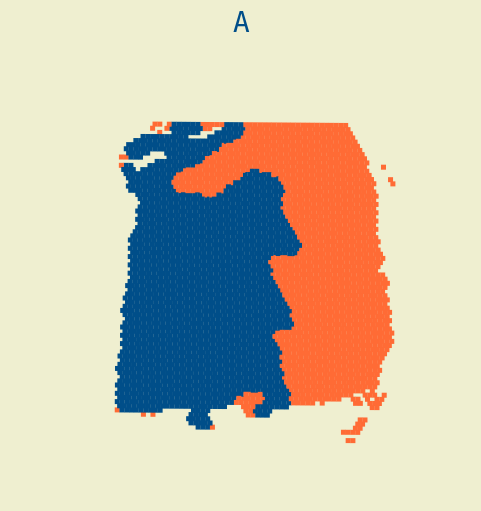

In [10]:
binaryMask0 = binaryMasks[8]
fig, ax = plt.subplots(1, 1, figsize=(5, 5),
                                           gridspec_kw={"width_ratios":[1.2]}, 
                                           constrained_layout=True)
plot_spatial_scatter(
    scdata, 
    binaryMask0, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax,
    title        = "A")

labels, comps, xxx = connected_components_on_mask(binaryMask0, vicini_filtrati, number_of_spots, min_size=5)

print(f"Trovati {len(comps)} cluster >=5 spot")
sizes = [len(c) for c in comps]
print("Taglie cluster:", sizes[:10], "...")

Trovati 3 cluster >=5 spot
Taglie cluster: [2372, 7, 10] ...


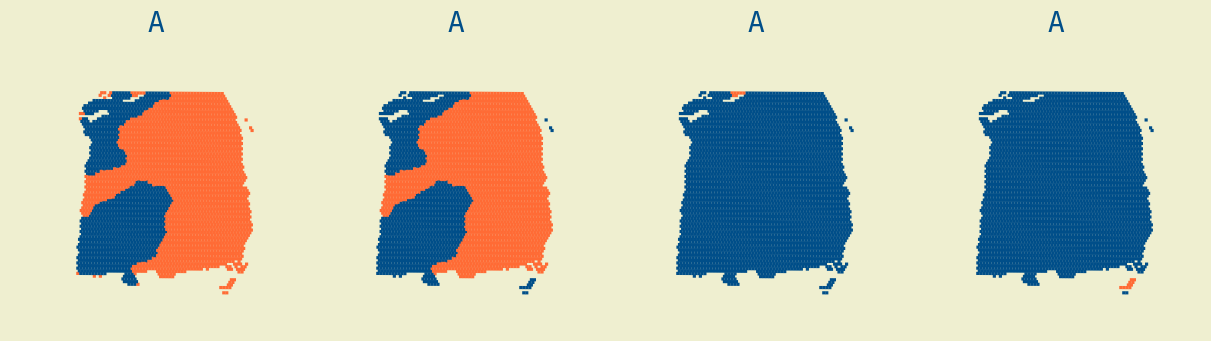

In [11]:
binaryMask0 = binaryMasks[5]
fig, (ax1,ax2,ax3,ax4) = plt.subplots(1, 4, figsize=(12, 5),
                                           gridspec_kw={"width_ratios":[1.2,1.2,1.2,1.2]}, 
                                           constrained_layout=True)
plot_spatial_scatter(
    scdata, 
    binaryMask0, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax1,
    title        = "A")



labels, comps, comp_mask = connected_components_on_mask(binaryMask0, vicini_filtrati, number_of_spots,min_size=5)

print(f"Trovati {len(comps)} cluster >=5 spot")
sizes = [len(c) for c in comps]
print("Taglie cluster:", sizes[:10], "...")


plot_spatial_scatter(
    scdata, 
    comp_mask[0], 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax2,
    title        = "A")
plot_spatial_scatter(
    scdata, 
    comp_mask[1], 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax3,
    title        = "A")
plot_spatial_scatter(
    scdata, 
    comp_mask[2], 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax4,
    title        = "A")

In [ ]:
def build_subgenes(binary_masks, neighbors, number_of_spots, min_size=1, gene_ids=None):

    if isinstance(binary_masks, np.ndarray) and binary_masks.ndim == 2:
        n_genes = binary_masks.shape[0]
        get_mask = lambda i: binary_masks[i]
    else:
        n_genes = len(binary_masks)
        get_mask = lambda i: np.asarray(binary_masks[i])

    if gene_ids is None:
        gene_ids = list(range(n_genes))

    results = []
    for gi in range(n_genes):
        mask = get_mask(gi)
        _, comps, comp_masks = connected_components_on_mask(
            mask, neighbors, number_of_spots, min_size=min_size, return_masks=True
        )
        for sub_id, (comp, cmask) in enumerate(zip(comps, comp_masks)):
            results.append({
                "gene_id": gene_ids[gi],
                "sub_id": sub_id,
                "count": len(comp),
                "comp_mask": cmask
            })
    return results

In [13]:
subgenes = build_subgenes(
    binary_masks=binaryMasks,           # list/array di shape (n_geni, n_spot) con 0/1
    neighbors=vicini_filtrati,
    number_of_spots=number_of_spots,
    min_size=5
)

# subgenes è una *lista* di record
print(len(subgenes), "sotto-geni trovati")
print(subgenes[0].keys())  # dict_keys(['gene_id','sub_id','count','comp_mask'])

3833 sotto-geni trovati
dict_keys(['gene_id', 'sub_id', 'count', 'comp_mask'])


In [14]:
np.save("subgenes",subgenes)

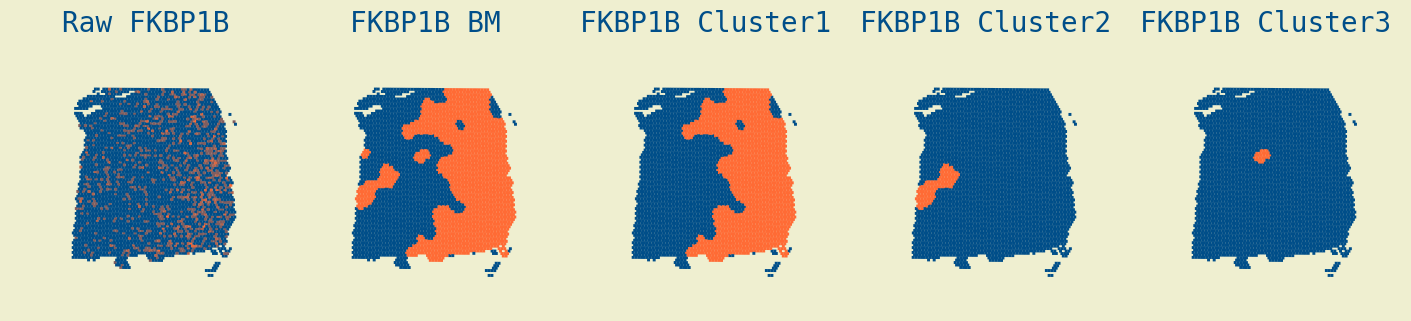

In [15]:
gene_id = 93
binaryMask0 = binaryMasks[gene_id]
fig, (ax0,ax1,ax2,ax3,ax4) = plt.subplots(1, 5, figsize=(14, 5),
                                           gridspec_kw={"width_ratios":[1.2,1.2,1.2,1.2,1.2]}, 
                                           constrained_layout=True)

plot_spatial_scatter(
    scdata, 
    np.sqrt(array_data[original_gene_ids[gene_id]]), 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax0,
    title        = "Raw "+gene_names[original_gene_ids[gene_id]])

plot_spatial_scatter(
    scdata, 
    binaryMask0, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax1,
    title        = gene_names[original_gene_ids[gene_id]]+" BM")


g8 = [r for r in subgenes if r["gene_id"] == gene_id]
plot_spatial_scatter(
    scdata, 
    g8[0]['comp_mask'], 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax2,
    title        = gene_names[original_gene_ids[gene_id]]+" Cluster1")
plot_spatial_scatter(
    scdata, 
    g8[1]['comp_mask'], 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax3,
    title        = gene_names[original_gene_ids[gene_id]]+" Cluster2")
plot_spatial_scatter(
    scdata, 
    g8[2]['comp_mask'], 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax4,
    title        = gene_names[original_gene_ids[gene_id]]+" Cluster3")

plt.savefig("presentazioneCerinelli/subGenes.png")

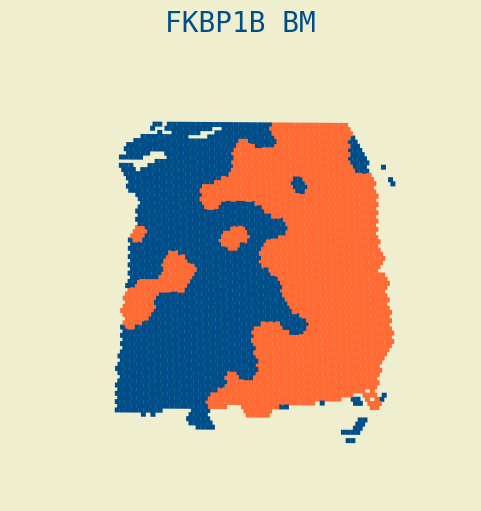

In [19]:
gene_id = 93
binaryMask0 = binaryMasks[gene_id]
fig, ax = plt.subplots(1, 1, figsize=(5, 5),
                                           gridspec_kw={"width_ratios":[1.2]}, 
                                           constrained_layout=True)
plot_spatial_scatter(
    scdata, 
    binaryMask0, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax,
    title        = gene_names[original_gene_ids[gene_id]]+" BM")

plt.savefig("presentazioneCerinelli/geneSingleWithSubGenesShow.png")

In [19]:
pappapero = np.load("subgenes.npy", allow_pickle=True)
print("CHCIHICICHHICHC")

CHCIHICICHHICHC
